In [418]:
"""
DAS Signal Processing — Submarine Cable Detection (SAC per-channel format)

Paper: Lin et al. (2025), JLT  — Zhoushan Archipelago experiment
Source: 50 kJ plasma pulse, primary frequency 100-400 Hz
DAS:   1000 Hz, 4 m channel spacing, gauge length 10 m
"""
import sys, warnings, os, glob, importlib
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from scipy.signal import butter, filtfilt, detrend, spectrogram
from scipy.signal import hilbert, correlate, welch
from scipy.ndimage import uniform_filter1d
from tqdm import tqdm

sys.path.insert(0, 'utils')
import plot_style as _ps
importlib.reload(_ps)
from plot_style import (apply_style, FigSize,
                        CMAP_BLUE, CMAP_RED, CMAP_BLUE_RED,
                        blue1, blue2, blue3, red1, red2, red3)
apply_style()

from scipy.stats import kurtosis as _kurt
try:
    import pywt;  HAS_PYWT = True
except ImportError:
    HAS_PYWT = False
    print("pywt not found — conda install -c conda-forge pywavelets")

# ── Consistent font sizes across all figures ──────────────────────────
FS_TICK  = 9    # tick labels
FS_LABEL = 10   # axis labels
FS_TITLE = 10   # subplot titles
FS_SUP   = 11   # suptitle
FS_LEG   = 9    # legends
plt.rcParams.update({
    "font.size":          FS_LABEL,
    "axes.titlesize":     FS_TITLE,
    "axes.labelsize":     FS_LABEL,
    "xtick.labelsize":    FS_TICK,
    "ytick.labelsize":    FS_TICK,
    "legend.fontsize":    FS_LEG,
    "figure.titlesize":   FS_SUP,
})
plt.rcParams["axes.grid"] = False


# =============================================================================
# Helper functions
# =============================================================================
base_folder  = "PubDAS_data/DAS data for submarine cable detection"
event_id     = 1          # excitation folder: 1–10

dx           = 4.08998    # m — channel spacing (from readme)
gauge_length = 10.0       # m — gauge length  (from readme)
c_water      = 1480       # m/s (measured in experiment area, paper)

aperture_km  = (1, 3)     # km — spatial aperture
t_window_full = None      # full record  ← use in plot cells
WIN_S, HOP_S  = 0.05, 0.01  # s — beamforming window / hop


# =============================================================================
# Read metadata
# =============================================================================
data_folder = os.path.join(base_folder, str(event_id))
files       = sorted(glob.glob(os.path.join(data_folder, 'Channel_*.sac')))
assert files, f"No SAC files found: {data_folder}"

n_space_all    = len(files)
_d0, delta, b0 = read_sac(files[0])
fs             = 1.0 / delta
n_time         = len(_d0);  del _d0

first_ch = max(0, int(np.round(aperture_km[0] * 1000 / dx)))
last_ch  = min(n_space_all - 1, int(np.round(aperture_km[1] * 1000 / dx)))
n_space  = last_ch - first_ch + 1
distance = np.arange(first_ch, last_ch + 1) * dx
time_vec = np.arange(n_time) * delta + b0

lowcut  = 1.0
highcut = min(c_water / (2 * dx), c_water / gauge_length)
P_MAX   = 1.0 / (2 * highcut * dx)

os.makedirs('plots', exist_ok=True)
print(f"Event     : {event_id}  ({data_folder})")
print(f"fs={fs:.0f} Hz | dx={dx:.4f} m | gauge={gauge_length:.1f} m")
print(f"Space     : {distance[0]/1000:.3f}–{distance[-1]/1000:.3f} km  ({n_space} channels)")
print(f"Full time : {time_vec[0]:.3f}–{time_vec[-1]:.3f} s  ({n_time} samples)")
print(f"Filters   : {lowcut:.0f}–{highcut:.1f} Hz")
print(f"P_MAX     : {P_MAX*1000:.3f} ms/m  (min speed {1/P_MAX:.0f} m/s)")

Event     : 1  (PubDAS_data/DAS data for submarine cable detection\1)
fs=1000 Hz | dx=4.0900 m | gauge=10.0 m
Space     : 0.998–2.998 km  (490 channels)
Full time : 0.000–4.950 s  (4951 samples)
Filters   : 1–148.0 Hz
P_MAX     : 0.826 ms/m  (min speed 1211 m/s)


In [419]:
def bandpass(data, fs, lowcut, highcut, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data)


def read_sac(fname):
    """Read a binary SAC file. Returns (data_float32, delta, b_time)."""
    with open(fname, 'rb') as f:
        raw = f.read()
    hf   = np.frombuffer(raw, dtype='<f4', count=70,  offset=0)
    hi   = np.frombuffer(raw, dtype='<i4', count=40,  offset=280)
    data = np.frombuffer(raw, dtype='<f4', count=int(hi[9]), offset=632).copy()
    return data, float(hf[0]), float(hf[5])


# =============================================================================
# Parameters  ← edit here
# =============================================================================


def snr_focused_db(sig, t_vec, t0):
    """SNR: signal = ±30 ms around t0, noise = before t0-20 ms."""
    noise_m  = t_vec < t0 - 0.02
    signal_m = (t_vec >= t0 - 0.03) & (t_vec <= t0 + 0.03)
    if noise_m.sum() < 5 or signal_m.sum() < 5:
        return float("nan")
    return 20 * np.log10(np.sqrt(np.mean(sig[signal_m]**2)) /
                         (np.sqrt(np.mean(sig[noise_m]**2)) + 1e-30))

# =============================================================================
# Focused DAS — CC-pick channel selection
# =============================================================================


# =============================================================================
# Helper + Signal Processing Functions
# =============================================================================
def _cosine_taper(x):
    """Cosine taper: 0 at x=0, 1 at x=1."""
    return 0.5 * (1 - np.cos(np.pi * np.clip(x, 0, 1)))


def fk_masks(aF2, aK2, c_ac=1500.0, c_sc_lo=200.0, taper_frac=0.2):
    """
    Cosine-tapered f-k masks — avoids Gibbs ringing from sharp boundaries.
    Returns mask_ac (acoustic, c≥1480 m/s) and mask_sc (Scholte, 200–1480 m/s).
    """
    with np.errstate(divide='ignore', invalid='ignore'):
        c_app = np.where(aK2 > 0, aF2 / aK2, np.inf)
    c_lo = c_ac * (1 - taper_frac);  c_hi = c_ac * (1 + taper_frac)
    taper_at_c_water = _cosine_taper((c_app - c_lo) / (c_hi - c_lo))
    mask_ac       = taper_at_c_water
    mask_sc_upper = 1.0 - taper_at_c_water
    lo_lo = c_sc_lo * (1 - taper_frac);  lo_hi = c_sc_lo * (1 + taper_frac)
    mask_sc = _cosine_taper((c_app - lo_lo) / (lo_hi - lo_lo)) * mask_sc_upper
    return mask_ac, mask_sc


def beamform(data, desc='Beam', p_scan=None):
    """Short-time plane-wave beamforming. p_scan overrides global P_SCAN."""
    win_samp = int(WIN_S * fs);  hop_samp = int(HOP_S * fs)
    n_t, n_x = data.shape;  rows, t_wins = [], []
    x_rel_f32 = x_rel.astype(np.float32)
    _p_scan   = p_scan if p_scan is not None else P_SCAN
    for t_start in range(0, n_t - win_samp, hop_samp):
        seg   = data[t_start:t_start+win_samp, :]
        F_seg = np.fft.rfft(seg, axis=0).astype(np.complex64)
        f_seg = np.fft.rfftfreq(win_samp, d=1/fs)
        fm    = (f_seg >= lowcut) & (f_seg <= highcut)
        F_b   = F_seg[fm, :]
        f_b   = f_seg[fm].astype(np.float32)
        row   = np.zeros(len(_p_scan), dtype=np.float32)
        for pi, p in enumerate(_p_scan):
            tau     = (2 * np.pi * float(p) * x_rel_f32)
            steer   = np.exp(-1j * np.outer(f_b, tau)).astype(np.complex64)
            b       = (steer * F_b).sum(axis=1) / n_x
            row[pi] = float(np.sum(np.abs(b)**2))
        rows.append(row / max(len(f_b), 1))
        t_wins.append(time_vec[t_start] + WIN_S / 2)
    return np.array(rows).T, np.array(t_wins)


def beamform_focused(data, x0_scan, z0_scan, t_win):
    """Focused (spherical-wave) beamforming — point source localization.

    Steering delay:  τₙ = ‖p − rₙ‖ / c
      p  = (x₀, z₀)  candidate source position
      rₙ = (xₙ,  0)  n-th channel position on fiber

    Sign convention:
      F_n(f) = A(f)·exp(-j2πf(t₀+τₙ))   [delay convention for rfft]
      Steer with exp(+j2πf·τₙ) to compensate → coherent sum at time t₀.

    Returns
    -------
    power : (n_x0, n_z0) float32
    """
    mt    = (time_vec >= t_win[0]) & (time_vec <= t_win[1])
    seg   = data[mt, :].copy()
    n_seg = seg.shape[0]

    tl  = max(1, int(0.1 * n_seg))
    tap = np.ones(n_seg, dtype=np.float32)
    tap[:tl]  = 0.5 * (1 - np.cos(np.pi * np.arange(tl) / tl))
    tap[-tl:] = 0.5 * (1 - np.cos(np.pi * np.arange(tl, 0, -1) / tl))
    seg *= tap[:, None]

    F_b = np.fft.rfft(seg, axis=0).astype(np.complex64)
    f_b = np.fft.rfftfreq(n_seg, d=1/fs).astype(np.float32)
    fm  = (f_b >= lowcut) & (f_b <= highcut)
    F_b = F_b[fm, :]                             # (n_freq, n_space)
    f_b = f_b[fm]

    x_rel_f32 = x_rel.astype(np.float32)
    z0_f32    = z0_scan.astype(np.float32)
    power     = np.zeros((len(x0_scan), len(z0_scan)), dtype=np.float32)

    for ix, x0 in enumerate(tqdm(
            x0_scan, desc='Focused beam',
            bar_format='{desc} {percentage:3.0f}%|{bar}| [{elapsed}<{remaining}]')):
        r   = np.sqrt((x_rel_f32 - float(x0))**2 + z0_f32[:, None]**2)
        tau = r / c_water                         # (n_z0, n_space)

        # +1j: exp(+j2πf·τₙ) compensates exp(-j2πf·τₙ) in data
        steer = np.exp(
            +1j * (2 * np.pi * f_b[:, None, None] * tau[None]).astype(np.float32)
        ).astype(np.complex64)

        b = (steer * F_b[:, None, :]).sum(axis=2) / n_space  # (n_freq, n_z0)
        power[ix] = (np.abs(b)**2).sum(axis=0)               # (n_z0,)

    return power


def to_db(arr):
    db = 10 * np.log10(arr + 1e-30)
    return db - db.max()


def plot_beamforming(BM_AC, TW, title, save_path, p_scan=None, ylim=None):
    """Short-time beamforming with explicit axes layout to avoid label overlap."""
    import matplotlib.patches as _pat
    _psc = p_scan if p_scan is not None else P_SCAN
    p_ac = 1000 / c_water

    fig = plt.figure(figsize=(10, 5))
    # Explicit positions [left, bottom, width, height] in figure fraction
    # Main axes ends at 0.57; gap 0.57-0.65 for angle labels;
    # colorbar 0.65-0.67; schematic 0.73-0.97
    ax   = fig.add_axes([0.07, 0.12, 0.50, 0.78])
    cbax = fig.add_axes([0.65, 0.12, 0.015, 0.78])
    ax_s = fig.add_axes([0.73, 0.08, 0.23, 0.84])

    # ── Beamforming image ────────────────────────────────────────────────
    ext = [TW[0], TW[-1], _psc[0]*1000, _psc[-1]*1000]
    im  = ax.imshow(BM_AC, aspect='auto', origin='lower', extent=ext,
                    cmap=CMAP_BLUE, vmin=-20, vmax=0)
    fig.colorbar(im, cax=cbax, label='Norm. power (dB)')

    for sgn in [1, -1]:
        ax.axhline(sgn * p_ac, color=red1, lw=1.8, ls='--',
                   label='1480 m/s' if sgn == 1 else '')
    yl = ylim if ylim is not None else (_psc[0]*1000, _psc[-1]*1000)
    ax.set_ylim(yl);  ax.set_xlim(TW[0], TW[-1])
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylabel('Slowness (ms/m)', fontsize=10)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_title('Short-time beamforming — Acoustic (c_app ≥ 1480 m/s)', fontsize=10)

    # ── Angle axis (twinx) — sits in gap between ax and cbax ────────────
    ax2 = ax.twinx()
    ax2.set_ylim(yl)
    yticks = np.array([t for t in ax.get_yticks() if yl[0] <= t <= yl[1]])
    def _lbl(p_ms):
        v = abs(p_ms) * 1e-3 * c_water
        if v > 1.0: return ''
        d = np.degrees(np.arcsin(v))
        return f'{d:.0f}°' if p_ms >= 0 else f'-{d:.0f}°'
    ax2.set_yticks(yticks)
    ax2.set_yticklabels([_lbl(p) for p in yticks], fontsize=10)
    ax2.set_ylabel('Incidence angle θ (°)', fontsize=10, labelpad=4)

    # ── Geometry schematic ───────────────────────────────────────────────
    ax_s.set_aspect('equal');  ax_s.axis('off')
    ax_s.set_xlim(-0.1, 1.1);  ax_s.set_ylim(-0.2, 1.15)

    ax_s.plot([0, 1.0], [0, 0], 'k-', lw=3)
    ax_s.text(0.5, -0.13, 'DAS cable', ha='center', fontsize=9)
    ax_s.plot([0.5, 0.5], [0, 1.05], '--', color='gray', lw=1.3)

    th = np.radians(40)
    rx = 0.5 - np.sin(th) * 0.85
    ry = np.cos(th) * 0.85
    ax_s.annotate('', xy=(0.5, 0.02), xytext=(rx, ry),
                  arrowprops=dict(arrowstyle='->', color='k', lw=2.0))
    ax_s.plot(rx, ry, '*', ms=13, color=red1, zorder=5)

    arc = _pat.Arc((0.5, 0), 0.50, 0.50, angle=0,
                   theta1=90, theta2=90 + np.degrees(th),
                   color='k', lw=1.8)
    ax_s.add_patch(arc)
    mid = np.radians(110)
    ax_s.text(0.5 + 0.30*np.cos(mid) - 0.04, 0.30*np.sin(mid),
              'θ', fontsize=16, fontweight='bold')

    ax_s.set_title('Geometry', fontsize=10, pad=4)

    fig.suptitle(title, fontsize=12, y=0.98)
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved {save_path}")


def plot_fk_spectrum(data, t_win, title, save_path, dyn_range=40):
    """Compute and plot f-k spectrum for a time window of data."""
    if t_win is not None:
        mt = (time_vec >= t_win[0]) & (time_vec <= t_win[1])
        d  = data[mt, :]
    else:
        d  = data
    n = d.shape[0]
    tl = max(1, int(0.1 * n))
    tap = np.ones(n, dtype=np.float32)
    tap[:tl]  = 0.5*(1 - np.cos(np.pi*np.arange(tl)/tl))
    tap[-tl:] = 0.5*(1 - np.cos(np.pi*np.arange(tl, 0, -1)/tl))
    sc   = np.nan_to_num(d * tap[:, None], nan=0.0)
    FK   = np.fft.fftshift(np.fft.fft2(sc))
    nt, nx = sc.shape
    fv   = np.fft.fftshift(np.fft.fftfreq(nt, d=1/fs))
    kv   = np.fft.fftshift(np.fft.fftfreq(nx, d=dx))
    db   = 20 * np.log10(np.abs(FK) + 1e-10)
    vmax = np.percentile(db, 99.5);  vmin = vmax - dyn_range
    t_str = f"{t_win[0]:.1f}–{t_win[1]:.1f} s" if t_win else "full record"
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(db, aspect='auto', origin='lower',
                   extent=[kv[0], kv[-1], fv[0], fv[-1]],
                   cmap=CMAP_BLUE, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, label='Power (dB)')
    for cref, col, ls, lw in [(c_water, red1, '--', 2.0), (200, red3, '--', 1.8)]:
        kr = np.abs(fv) / cref
        ax.plot( kr, fv, ls, lw=lw, color=col, label=f'{cref} m/s')
        ax.plot(-kr, fv, ls, lw=lw, color=col)
    ax.set_xlim(-np.abs(kv).max(), np.abs(kv).max())
    ax.set_ylim(-highcut, highcut)
    ax.set_xlabel('Wavenumber (cycles/m)');  ax.set_ylabel('Frequency (Hz)')
    ax.set_title(f'{title}  [{t_str}  nt={nt}  Δf={fs/nt:.1f} Hz]')
    ax.legend(loc='upper right', fontsize=8);  ax.grid(False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150);  plt.show();  print(f"Saved {save_path}")

In [420]:
# =============================================================================
# Processing — load all channels, filter, f-k separation, beamforming
# (set event_id / section_space / lowcut / highcut in the parameters cell above)
# =============================================================================
# WIN_S and HOP_S are set per-dataset in Cell 0
N_P = 80
# Global P_SCAN (acoustic, strict Nyquist)
P_MAX_ac  = 1.0 / (2 * highcut * dx)
P_SCAN    = np.linspace(-P_MAX_ac, P_MAX_ac, N_P)  # backward-compat
P_SCAN_ac = P_SCAN

# Scholte P_SCAN: Nyquist at 20 Hz → covers down to ~200 m/s
P_MAX_sc  = min(5.0e-3, 1.0 / (2 * 20.0 * dx))
P_SCAN_sc = np.linspace(-P_MAX_sc, P_MAX_sc, N_P)
print(f"P_MAX_ac={P_MAX_ac*1000:.2f} ms/m  P_MAX_sc={P_MAX_sc*1000:.2f} ms/m")
x_rel   = distance - distance[0]
PX      = np.outer(P_SCAN, x_rel)
WIN_E   = int(1.0 * fs);  SKIP_E = WIN_E

print(f"Beamform: WIN={WIN_S}s HOP={HOP_S}s | slowness ±{P_MAX*1000:.1f} ms/m ({1/P_MAX:.0f}–∞ m/s)")

# =============================================================================
# Load SAC channels → raw (n_time, n_space)    ← run once per event_id change
# =============================================================================
print(f"Loading {n_space} channels for event {event_id} ...")
raw = np.zeros((n_time, n_space), dtype=np.float32)
for i, ch_idx in enumerate(tqdm(range(first_ch, last_ch + 1),
                                 bar_format='{desc} {percentage:3.0f}%|{bar}| {n}/{total} [{elapsed}<{remaining}]')):
    data, _, _ = read_sac(files[ch_idx])
    raw[:, i]  = data
# t_window applies only in plot cells — full 4.95 s kept for all processing
print(f"Loaded: raw shape = {raw.shape}")


P_MAX_ac=0.83 ms/m  P_MAX_sc=5.00 ms/m
Beamform: WIN=0.05s HOP=0.01s | slowness ±0.8 ms/m (1211–∞ m/s)
Loading 490 channels for event 1 ...


 100%|██████████| 490/490 [00:05<00:00]

Loaded: raw shape = (4951, 490)


In [421]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 2: Bad channel detection and interpolation
# ─────────────────────────────────────────────────────────────────────────────
rms_c = np.sqrt(np.nanmean(raw**2, axis=0))
med_c = np.nanmedian(rms_c)
bm_c  = np.isnan(rms_c) | (rms_c > 5*med_c) | (rms_c < 0.1*med_c)
sr    = raw.copy()
for idx in np.where(bm_c)[0]:
    l, r = idx-1, idx+1
    while l >= 0       and bm_c[l]: l -= 1
    while r <  n_space and bm_c[r]: r += 1
    if   l >= 0 and r < n_space: sr[:, idx] = 0.5*(raw[:, l]+raw[:, r])
    elif l >= 0:                  sr[:, idx] = raw[:, l]
    else:                         sr[:, idx] = raw[:, r]
print(f"Bad channels: {bm_c.sum()} / {n_space}")

# ─────────────────────────────────────────────────────────────────────────────
# Step 3: Detrend + Bandpass filter
# Detrend removes per-channel DC/linear drift before filtering,
# so lowcut can be as low as 1 Hz without large edge transients.
# ─────────────────────────────────────────────────────────────────────────────
sr_dt = detrend(sr, axis=0, type='linear').astype(np.float32)
sf = np.zeros_like(sr_dt)
for ch in tqdm(range(n_space), desc='Bandpass',
               bar_format='{desc} {percentage:3.0f}%|{bar}| {n}/{total} [{elapsed}<{remaining}]'):
    sf[:, ch] = bandpass(sr_dt[:, ch], fs, lowcut, highcut)
strain_filtered = sf
print(f"Preprocessing done | filtered shape = {sf.shape}")

Bad channels: 0 / 490


Bandpass 100%|██████████| 490/490 [00:01<00:00]

Preprocessing done | filtered shape = (4951, 490)


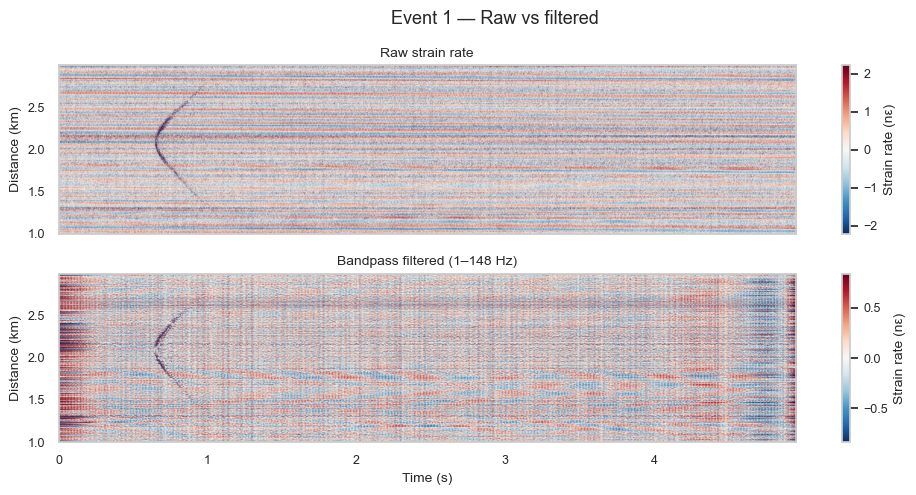

Saved plots/raw_vs_filtered.png


In [422]:
# =============================================================================
# Waterfall — raw vs bandpass-filtered strain rate
# =============================================================================
t_window = t_window_full   # change to t_window_pulse for pulse zoom

if t_window:
    mt       = (time_vec >= t_window[0]) & (time_vec <= t_window[1])
    tv       = time_vec[mt]
    raw_plot = raw[mt, :]
    sf_plot  = strain_filtered[mt, :]
else:
    tv, raw_plot, sf_plot = time_vec, raw, strain_filtered

ext = [tv[0], tv[-1], distance[0]/1000, distance[-1]/1000]

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, sharey=True)
for ax, (d, title) in zip(axes, [
        (raw_plot, "Raw strain rate"),
        (sf_plot,  f"Bandpass filtered ({lowcut:.0f}–{highcut:.0f} Hz)")]):
    clim = np.nanpercentile(np.abs(d), 98)
    im = ax.imshow(d.T, aspect='auto', origin='lower',
                   extent=ext, cmap='RdBu_r', vmin=-clim, vmax=clim)
    plt.colorbar(im, ax=ax, label='Strain rate (nε)')
    ax.set_ylabel('Distance (km)')
    ax.set_title(title)
axes[-1].set_xlabel('Time (s)')
plt.suptitle(f'Event {event_id} — Raw vs filtered', fontsize=13)
plt.tight_layout()
plt.savefig(f'plots/raw_vs_filtered.png', dpi=150)
plt.show()
print(f"Saved plots/raw_vs_filtered.png")

Auto-detected event: t = 0.646–1.146 s
Nearest source channel: idx=539  dist=2.204 km  peak=21.686 nε


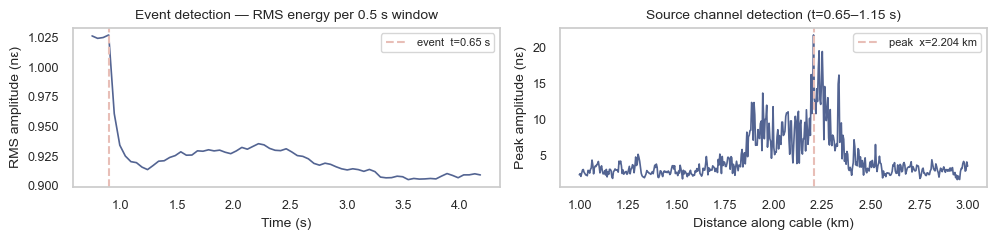

In [423]:
# =============================================================================
# §4 EVENT DETECTION
# Sliding-window RMS energy locates the event in time; peak amplitude channel
# locates the source along the cable. No prior knowledge required.
# Note: replaceable by ML anomaly detector (Isolation Forest, LSTM) trained
# on the 7-feature vector from the single-channel analysis.
#
# No prior knowledge of pulse time required.
# Slide a 0.5 s window over the record and find the window with maximum
# amplitude. Then find the channel with the highest amplitude in that window.
# =============================================================================
WIN_D      = 0.5                    # detection window (s)
win_samp_d = int(WIN_D * fs)
hop_samp_d = max(1, int(0.05 * fs)) # 50 ms hop

# Skip filter edges (first/last 0.5 s)
i_st = int(0.5 * fs)
i_en = n_time - int(0.5 * fs) - win_samp_d
starts_d  = list(range(i_st, i_en, hop_samp_d))
e_win     = np.array([np.sqrt(np.mean(raw[i:i+win_samp_d, :]**2)) for i in starts_d])
t_wins_d  = np.array([time_vec[i] + WIN_D/2 for i in starts_d])

i_ev      = int(np.argmax(e_win))
t_ev_0    = time_vec[starts_d[i_ev]]
t_ev_1    = t_ev_0 + WIN_D

mt_event  = (time_vec >= t_ev_0) & (time_vec < t_ev_1)
peak_amp  = np.max(np.abs(raw[mt_event, :]), axis=0)
ch_local  = int(np.argmax(peak_amp))
ch_idx    = first_ch + ch_local
ch_dist   = distance[ch_local] / 1000
print(f"Auto-detected event: t = {t_ev_0:.3f}–{t_ev_1:.3f} s")
print(f"Nearest source channel: idx={ch_idx}  dist={ch_dist:.3f} km  "
      f"peak={peak_amp[ch_local]:.3f} nε")

fig, axes = plt.subplots(1, 2, figsize=(10, 2.5))

axes[0].plot(t_wins_d, e_win, color=blue2, lw=1.2)
axes[0].axvline(t_ev_0 + WIN_D/2, color=red1, ls='--', lw=1.5,
                label=f'event  t={t_ev_0:.2f} s')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('RMS amplitude (nε)')
axes[0].set_title('Event detection — RMS energy per 0.5 s window')
axes[0].legend(fontsize=8)

axes[1].plot(distance/1000, peak_amp, color=blue2, lw=1.2)
axes[1].axvline(ch_dist, color=red1, ls='--', lw=1.5,
                label=f'peak  x={ch_dist:.3f} km')
axes[1].set_xlabel('Distance along cable (km)')
axes[1].set_ylabel('Peak amplitude (nε)')
axes[1].set_title(f'Source channel detection (t={t_ev_0:.2f}–{t_ev_1:.2f} s)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'plots/peak_amplitude.png', dpi=150)
plt.show()

Analysis channel: idx=539  x=2.204 km
Windows: 14  (win=0.5 s, hop=0.25 s)


C:\Users\20215518\AppData\Local\Temp\ipykernel_18460\3060841943.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


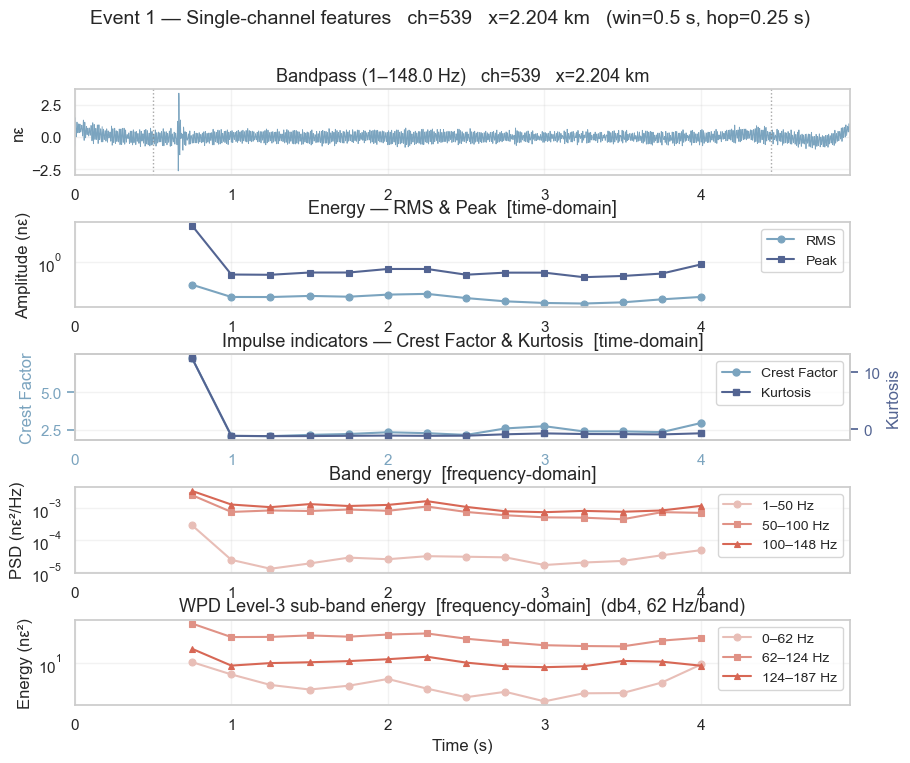

Saved  ch=539  x=2.204 km


In [424]:
# ═══════════════════════════════════════════════════════════════════════════
# (i)  FEATURE ENGINEERING — Single Channel  (§3)
# 7 features in a sliding window (0.5 s, hop 0.25 s):
#   Time : RMS, Peak, Crest Factor, Kurtosis
#   Freq : Band energy Lo/Mid/Hi, Wavelet Packet Decomposition (db4, L3)
# These features feed downstream anomaly detection and event classification.
# ═══════════════════════════════════════════════════════════════════════════

sig_an = strain_filtered[:, ch_local]
print(f"Analysis channel: idx={ch_idx}  x={ch_dist:.3f} km")

FEAT_WIN = 0.5;  FEAT_HOP = 0.25
T_S = 0.5;  T_E = time_vec[-1] - 0.5

wins = [];  t_mid_f = []
t = T_S
while t + FEAT_WIN <= T_E:
    wins.append((t, t + FEAT_WIN));  t_mid_f.append(t + FEAT_WIN / 2);  t += FEAT_HOP
t_mid_f = np.array(t_mid_f);  NW = len(wins)
print(f"Windows: {NW}  (win={FEAT_WIN} s, hop={FEAT_HOP} s)")

WPD_LV = 3;  WPD_N = 2**WPD_LV;  WPD_BW = (fs/2)/WPD_N
n_rel  = sum(1 for i in range(WPD_N) if i * WPD_BW < highcut)
wpd_labels = [f'{int(i*WPD_BW)}–{int((i+1)*WPD_BW)} Hz' for i in range(n_rel)]

rms_v   = np.zeros(NW);  peak_v  = np.zeros(NW);  crest_v = np.zeros(NW)
kurt_v  = np.zeros(NW)
blo_v   = np.zeros(NW);  bmid_v  = np.zeros(NW);  bhi_v   = np.zeros(NW)
wpd_v   = np.zeros((NW, WPD_N))

for wi, (t0, t1) in enumerate(wins):
    mt  = (time_vec >= t0) & (time_vec < t1)
    seg = sig_an[mt].astype(np.float64)
    n   = len(seg)
    if n < 20:
        continue
    rms  = float(np.sqrt(np.mean(seg**2)));  peak = float(np.max(np.abs(seg)))
    rms_v[wi] = rms;  peak_v[wi] = peak
    crest_v[wi] = peak / (rms + 1e-30)
    kurt_v[wi]  = float(_kurt(seg))
    f_p, Pxx = welch(seg, fs=fs, nperseg=min(n, 256))
    fm_b = (f_p >= lowcut) & (f_p <= highcut);  f_b, Pxx_b = f_p[fm_b], Pxx[fm_b]
    if f_b.size:
        blo_v[wi]  = float(np.mean(Pxx_b[f_b < 50]))            if (f_b < 50).any()             else 0
        bmid_v[wi] = float(np.mean(Pxx_b[(f_b>=50)&(f_b<100)])) if ((f_b>=50)&(f_b<100)).any() else 0
        bhi_v[wi]  = float(np.mean(Pxx_b[f_b >= 100]))           if (f_b >= 100).any()           else 0
    if HAS_PYWT and n >= 32:
        try:
            wp    = pywt.WaveletPacket(seg, wavelet='db4', mode='symmetric', maxlevel=WPD_LV)
            nodes = wp.get_level(WPD_LV, 'freq')
            for ni, nd in enumerate(nodes):
                wpd_v[wi, ni] = float(np.sum(nd.data**2))
        except Exception:
            pass

# ── Plot ──────────────────────────────────────────────────────────────────
FS  = 12
FST = 13
MS  = 5
MKW = 0.8

TD = [(blue1, 'o'), (blue2, 's')]
FD = [(red1,  'o'), (red2,  's'), (red3, '^')]

fig = plt.figure(figsize=(10, 8))
gs  = fig.add_gridspec(5, 1, height_ratios=[2, 2, 2, 2, 2], hspace=0.55)
ax0 = fig.add_subplot(gs[0])
axes = [ax0] + [fig.add_subplot(gs[i], sharex=ax0) for i in range(1, 5)]
X0, X1 = time_vec[0], time_vec[-1]

def _fmt(ax, ylabel, title):
    ax.set_ylabel(ylabel, fontsize=FS)
    ax.set_title(title, fontsize=FST)
    ax.tick_params(labelsize=FS-1)
    ax.margins(x=0.01);  ax.grid(True, alpha=0.25)
    ax.set_xlim(X0, X1)

def _plot(ax, x, y, col, mk, label, lw=1.5, ls='-'):
    ax.plot(x, y, color=col, marker=mk, markersize=MS,
            markeredgewidth=MKW, lw=lw, ls=ls, label=label)

axes[0].plot(time_vec, sig_an, color=blue1, lw=0.6)
axes[0].axvline(T_S, color='grey', lw=1.0, ls=':', alpha=0.7)
axes[0].axvline(T_E, color='grey', lw=1.0, ls=':', alpha=0.7)
_fmt(axes[0], 'nε',
     f'Bandpass ({lowcut:.0f}–{highcut:.1f} Hz)   ch={ch_idx}   x={ch_dist:.3f} km')
axes[0].margins(x=0)

ax = axes[1]
_plot(ax, t_mid_f, rms_v,  blue1, 'o', 'RMS')
_plot(ax, t_mid_f, peak_v, blue2, 's', 'Peak')
ax.set_yscale('log')
_fmt(ax, 'Amplitude (nε)', 'Energy — RMS & Peak  [time-domain]')
ax.legend(fontsize=FS-2, ncol=1)

ax = axes[2];  ax2 = ax.twinx()
l1, = ax.plot(t_mid_f, crest_v,
              color=TD[0][0], marker=TD[0][1], markersize=MS, lw=1.5,
              label='Crest Factor')
l2, = ax2.plot(t_mid_f, kurt_v,
               color=TD[1][0], marker=TD[1][1], markersize=MS, lw=1.5,
               label='Kurtosis')
ax.set_ylabel('Crest Factor', color=TD[0][0], fontsize=FS)
ax2.set_ylabel('Kurtosis',    color=TD[1][0], fontsize=FS)
ax.tick_params(labelsize=FS-1, colors=TD[0][0])
ax2.tick_params(labelsize=FS-1, colors=TD[1][0])
ax.set_title('Impulse indicators — Crest Factor & Kurtosis  [time-domain]', fontsize=FST)
ax.legend(handles=[l1, l2], fontsize=FS-2, ncol=1, loc='upper right')
ax.margins(x=0.01);  ax.grid(True, alpha=0.25);  ax.set_xlim(X0, X1)

ax = axes[3]
for (col, mk), lbl, y in zip(FD, ['1–50 Hz', '50–100 Hz', '100–148 Hz'],
                               [blo_v, bmid_v, bhi_v]):
    _plot(ax, t_mid_f, y + 1e-30, col, mk, lbl)
ax.set_yscale('log')
_fmt(ax, 'PSD (nε²/Hz)', 'Band energy  [frequency-domain]')
ax.legend(fontsize=FS-2, ncol=1)

ax = axes[4]
if HAS_PYWT and np.any(wpd_v[:, :n_rel] > 0):
    for ni in range(n_rel):
        col, mk = FD[ni]
        _plot(ax, t_mid_f, wpd_v[:, ni] + 1e-30, col, mk, wpd_labels[ni])
    ax.set_yscale('log')
    _fmt(ax, 'Energy (nε²)',
         f'WPD Level-{WPD_LV} sub-band energy  [frequency-domain]  '
         f'(db4, {WPD_BW:.0f} Hz/band)')
    ax.legend(fontsize=FS-2, ncol=1)
else:
    ax.text(0.5, 0.5, 'WPD not available\nconda install -c conda-forge pywavelets',
            ha='center', va='center', transform=ax.transAxes, fontsize=FS)
    ax.set_title(f'WPD Level-{WPD_LV} sub-band energy  (db4)', fontsize=FST)
    ax.set_xlim(X0, X1)

axes[-1].set_xlabel('Time (s)', fontsize=FS)
axes[-1].tick_params(labelsize=FS-1)

fig.suptitle(f'Event {event_id} — Single-channel features   '
             f'ch={ch_idx}   x={ch_dist:.3f} km   '
             f'(win={FEAT_WIN} s, hop={FEAT_HOP} s)',
             fontsize=FST+1)
plt.tight_layout()
plt.savefig(f'plots/features_ch{ch_idx}.png', dpi=150)
plt.show()
print(f'Saved  ch={ch_idx}  x={ch_dist:.3f} km')

Anomalous segment: 0.500–1.000 s  (1 windows, pad=0.25 s)


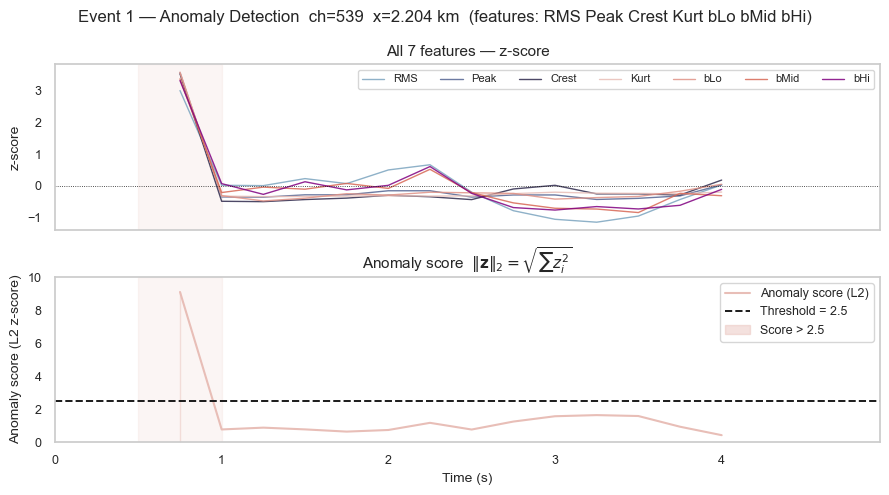

Saved plots/anomaly_detection.png


In [425]:
# ═══════════════════════════════════════════════════════════════════════════
# (i-b)  ANOMALY DETECTION  (§4)
# ─────────────────────────────────────────────────────────────────────────
# 7 features z-scored and combined: score = norm(z, L2).
# Outputs t_window_anomaly — gates all multi-channel analyses.
# Note: replace with Isolation Forest or Autoencoder for unsupervised use.
# ═══════════════════════════════════════════════════════════════════════════
ANOMALY_THRESH = 2.5          # threshold on combined L2 z-score
PAD_S          = FEAT_WIN / 2  # 0.25 s padding on each side of detected segment

feat_names = ['RMS', 'Peak', 'Crest', 'Kurt', 'bLo', 'bMid', 'bHi']
feat_mat   = np.stack([rms_v, peak_v, crest_v, kurt_v, blo_v, bmid_v, bhi_v], axis=1)
feat_z     = (feat_mat - feat_mat.mean(axis=0)) / (feat_mat.std(axis=0) + 1e-30)
anomaly_score = np.linalg.norm(feat_z, axis=1)   # (NW,)
anom_mask     = anomaly_score > ANOMALY_THRESH
anom_wins     = t_mid_f[anom_mask]

if anom_wins.size > 0:
    t_window_anomaly = (max(time_vec[0],  anom_wins[0]  - PAD_S),
                        min(time_vec[-1], anom_wins[-1] + PAD_S))
    print(f"Anomalous segment: {t_window_anomaly[0]:.3f}–{t_window_anomaly[1]:.3f} s  "
          f"({anom_mask.sum()} windows, pad={PAD_S:.2f} s)")
else:
    t_window_anomaly = (t_ev_0, t_ev_1)
    print(f"No anomaly above threshold — fallback to event window: "
          f"{t_window_anomaly[0]:.3f}–{t_window_anomaly[1]:.3f} s")

t0_an, t1_an = t_window_anomaly

# ── Plot ──────────────────────────────────────────────────────────────────────────
colors7 = [blue1, blue2, blue3, red1, red2, red3, 'purple']
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

# ── Top: 7 z-score features + anomaly window band ─────────────────────────────
for ni, (name, col) in enumerate(zip(feat_names, colors7)):
    axes[0].plot(t_mid_f, feat_z[:, ni], color=col, lw=1.0, alpha=0.85, label=name)
axes[0].axhline(0, color='k', lw=0.6, ls=':')
axes[0].axvspan(t0_an, t1_an, color=red1, alpha=0.15, zorder=0)
axes[0].set_ylabel('z-score', fontsize=10)
axes[0].set_title('All 7 features — z-score', fontsize=11)
axes[0].legend(fontsize=8, ncol=7, loc='upper right')
axes[0].margins(x=0.01)

# ── Bottom: combined score + threshold + window ────────────────────────────────
axes[1].plot(t_mid_f, anomaly_score, color=red1, lw=1.5, label='Anomaly score (L2)')
axes[1].axhline(ANOMALY_THRESH, color='k', ls='--', lw=1.4,
                label=f'Threshold = {ANOMALY_THRESH}')
axes[1].fill_between(t_mid_f, 0, anomaly_score,
                     where=anom_mask, color=red1, alpha=0.45,
                     label=f'Score > {ANOMALY_THRESH}')
axes[1].axvspan(t0_an, t1_an, color=red1, alpha=0.15, zorder=0)
ymax = anomaly_score.max() * 1.1
axes[1].set_ylim(0, ymax)
axes[1].set_ylabel('Anomaly score (L2 z-score)', fontsize=10)
axes[1].set_xlabel('Time (s)', fontsize=10)
axes[1].set_title(r'Anomaly score  $\|\mathbf{z}\|_2 = \sqrt{\sum z_i^2}$', fontsize=11)
axes[1].legend(fontsize=9, loc='upper right')
axes[1].set_xlim(time_vec[0], time_vec[-1])
axes[1].margins(x=0.01)

plt.suptitle(f'Event {event_id} — Anomaly Detection  ch={ch_idx}  x={ch_dist:.3f} km  '
             f'(features: {" ".join(feat_names)})',
             fontsize=12)
plt.tight_layout()
plt.savefig(f'plots/anomaly_detection.png', dpi=150)
plt.show()
print(f"Saved plots/anomaly_detection.png")

f-k done | acoustic: ±3.509e+00  scholte: ±1.395e+00


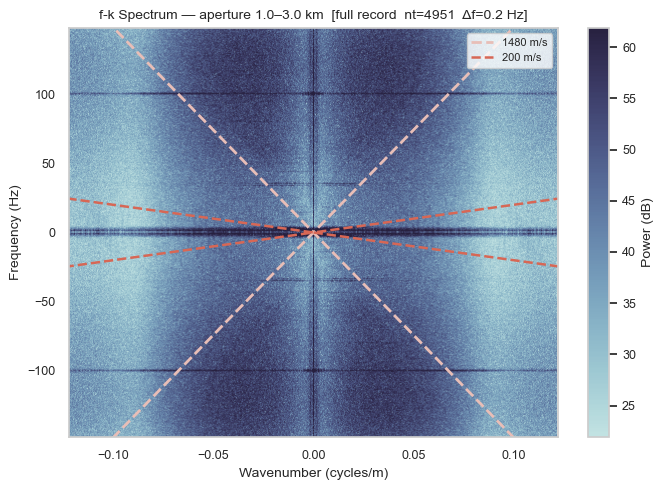

Saved plots/fk_spectrum.png


In [426]:
# ═══════════════════════════════════════════════════════════════════════════
# (ii)  WAVE-TYPE SEPARATION — f-k FILTERING  (§5)
# Cosine-tapered 2-D masks: Acoustic c>=1480 m/s | Scholte 200-1480 m/s
# ═══════════════════════════════════════════════════════════════════════════
# =============================================================================
# f-k separation (cosine-tapered masks) — full record
# =============================================================================
_tlen  = int(0.1 * n_time)
_taper = np.ones(n_time, dtype=np.float32)
_taper[:_tlen]  = 0.5*(1 - np.cos(np.pi*np.arange(_tlen)/_tlen))
_taper[-_tlen:] = 0.5*(1 - np.cos(np.pi*np.arange(_tlen, 0, -1)/_tlen))
sc_clean = np.nan_to_num(sf * _taper[:, None], nan=0.0)
FK2      = np.fft.fftshift(np.fft.fft2(sc_clean))
nt2, nx2 = sc_clean.shape
fq2      = np.fft.fftshift(np.fft.fftfreq(nt2, d=1/fs))
kv2      = np.fft.fftshift(np.fft.fftfreq(nx2, d=dx))
FF2, KK2 = np.meshgrid(fq2, kv2, indexing='ij')
aF2, aK2 = np.abs(FF2), np.abs(KK2)
mask_ac2, mask_sc2 = fk_masks(aF2, aK2, c_ac=c_water)
strain_acoustic = np.real(np.fft.ifft2(np.fft.ifftshift(FK2 * mask_ac2)))
strain_scholte  = np.real(np.fft.ifft2(np.fft.ifftshift(FK2 * mask_sc2)))
print(f"f-k done | acoustic: ±{np.abs(strain_acoustic).max():.3e}  "
      f"scholte: ±{np.abs(strain_scholte).max():.3e}")

# =============================================================================
# f-k Spectrum — full record
# =============================================================================
plot_fk_spectrum(
    sf, t_window_full,
    f'f-k Spectrum — aperture {aperture_km[0]:.1f}–{aperture_km[1]:.1f} km',
    'plots/fk_spectrum.png')

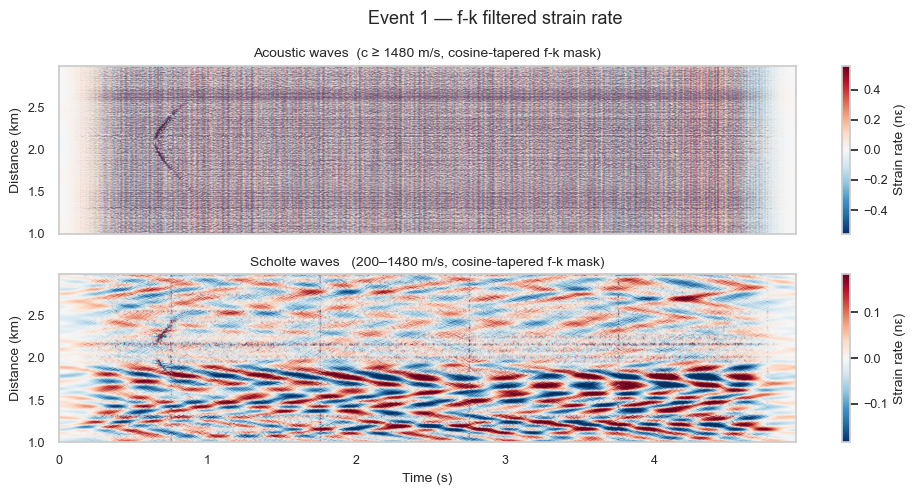

Saved plots/fk_strain.png


In [427]:
# =============================================================================
# f-k filtered strain rate— acoustic and Scholte waves
# =============================================================================
# t_window_full / t_window_pulse defined in Cell 0
t_window = t_window_full   # change to t_window_pulse for pulse zoom

if t_window:
    mt      = (time_vec >= t_window[0]) & (time_vec <= t_window[1])
    tv      = time_vec[mt]
    ac_plot = strain_acoustic[mt, :]
    sc_plot = strain_scholte[mt, :]
else:
    tv, ac_plot, sc_plot = time_vec, strain_acoustic, strain_scholte

ext = [tv[0], tv[-1], distance[0]/1000, distance[-1]/1000]

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, sharey=True)
_datasets = [
    (ac_plot, "Acoustic waves  (c ≥ 1480 m/s, cosine-tapered f-k mask)"),
    (sc_plot, "Scholte waves   (200–1480 m/s, cosine-tapered f-k mask)"),
]
for ax, (d, title) in zip(axes, _datasets):
    clim = np.nanpercentile(np.abs(d), 95)
    im = ax.imshow(d.T, aspect='auto', origin='lower',
                   extent=ext, cmap='RdBu_r', vmin=-clim, vmax=clim)
    plt.colorbar(im, ax=ax, label='Strain rate (nε)')
    ax.set_ylabel('Distance (km)')
    ax.set_title(title)
axes[-1].set_xlabel('Time (s)')
plt.suptitle(f'Event {event_id} — f-k filtered strain rate', fontsize=13)
plt.tight_layout()
plt.savefig(f'plots/fk_strain.png', dpi=150)
plt.show()
print(f"Saved plots/fk_strain.png")


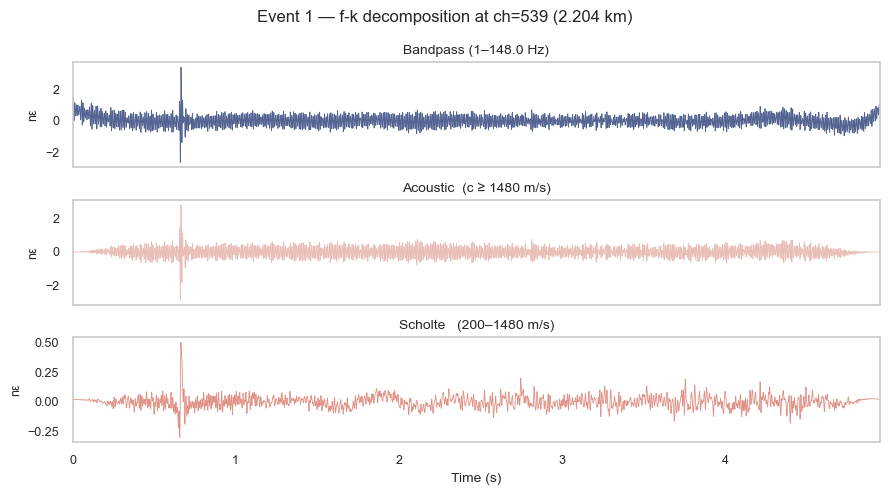

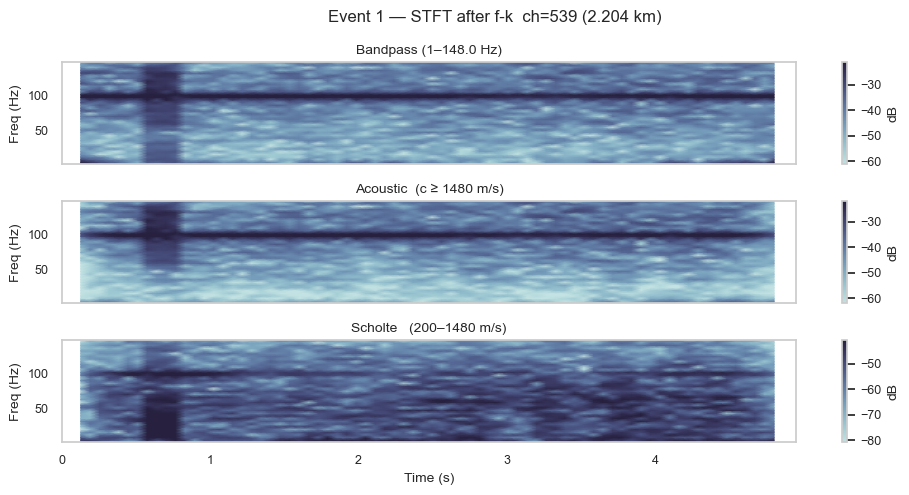

Saved f-k single-channel plots for ch=539


In [428]:
# =============================================================================
# Single-channel f-k decomposition (peak channel from section i)
# Shows the effect of f-k filtering on a single trace
# =============================================================================
t_window = t_window_full   # change to t_window_pulse for pulse zoom
if t_window:
    mt        = (time_vec >= t_window[0]) & (time_vec <= t_window[1])
    tv_fk     = time_vec[mt]
    sf_ch_fk  = strain_filtered[mt, ch_local]
    ac_ch     = strain_acoustic[mt, ch_local]
    sc_ch     = strain_scholte[mt, ch_local]
else:
    tv_fk     = time_vec
    sf_ch_fk  = strain_filtered[:, ch_local]
    ac_ch     = strain_acoustic[:, ch_local]
    sc_ch     = strain_scholte[:, ch_local]

# ── Time series: bandpass → acoustic → scholte ────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(9, 5), sharex=True)
for ax, (data, lbl, col) in zip(axes, [
        (sf_ch_fk,  f"Bandpass ({lowcut:.0f}–{highcut:.1f} Hz)", blue2),
        (ac_ch,     "Acoustic  (c ≥ 1480 m/s)",               red1),
        (sc_ch,     "Scholte   (200–1480 m/s)",                red2)]):
    ax.plot(tv_fk, data, color=col, lw=0.6)
    ax.set_ylabel("nε", fontsize=9)
    ax.set_title(lbl, fontsize=10)
    ax.margins(x=0)
axes[-1].set_xlabel("Time (s)")
plt.suptitle(f"Event {event_id} — f-k decomposition at ch={ch_idx} ({ch_dist:.3f} km)", fontsize=12)
plt.tight_layout()
plt.savefig(f"plots/fk_single_ch{ch_idx}.png", dpi=150)
plt.show()

# ── STFT: bandpass → acoustic → scholte ──────────────────────────────────────
nperseg  = min(256, n_time // 8)
noverlap = nperseg * 3 // 4
fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
for ax, (sig, lbl) in zip(axes, [
        (sf_ch_fk,  f'Bandpass ({lowcut:.0f}–{highcut:.1f} Hz)'),
        (ac_ch,     'Acoustic  (c ≥ 1480 m/s)'),
        (sc_ch,     'Scholte   (200–1480 m/s)')]):
    ff, tt, Sxx = spectrogram(sig, fs=fs, nperseg=nperseg, noverlap=noverlap)
    Sdb = 10 * np.log10(Sxx + 1e-30)
    vmax_s = np.percentile(Sdb, 99)
    im = ax.pcolormesh(tt + tv_fk[0], ff, Sdb,
                       shading='gouraud', cmap=CMAP_BLUE,
                       vmin=vmax_s - 40, vmax=vmax_s)
    plt.colorbar(im, ax=ax, label='dB')
    ax.set_ylabel('Freq (Hz)')
    ax.set_xlim(tv_fk[0], tv_fk[-1])
    ax.set_title(lbl, fontsize=10)
    ax.set_ylim(lowcut, highcut)
axes[-1].set_xlabel('Time (s)')
plt.suptitle(f'Event {event_id} — STFT after f-k  ch={ch_idx} ({ch_dist:.3f} km)', fontsize=12)
plt.tight_layout()
plt.savefig(f'plots/stft_fk_ch{ch_idx}.png', dpi=150)
plt.show()
print(f'Saved f-k single-channel plots for ch={ch_idx}')

Beamforming on anomalous segment: 0.500–1.000 s  (500 samples, 0.500 s) ...


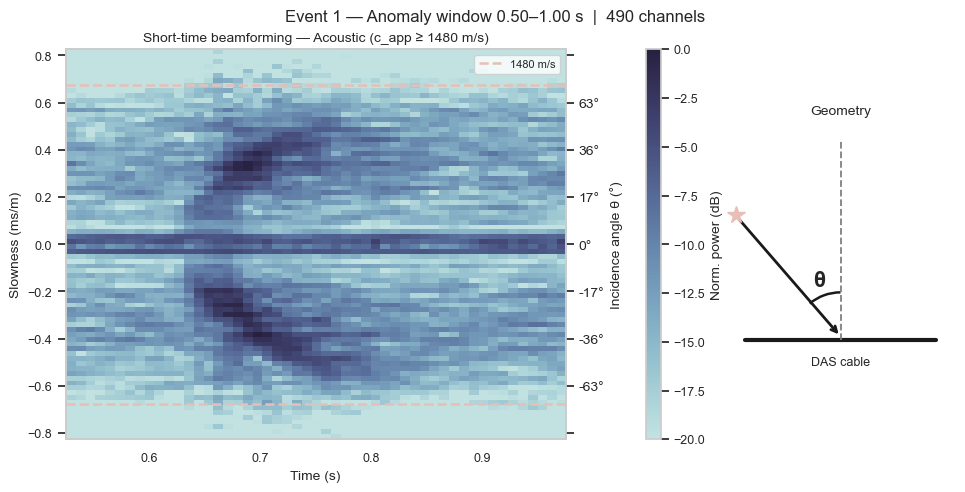

Saved plots/beamforming_anomaly.png


In [429]:
# ═══════════════════════════════════════════════════════════════════════════
# (iii)  BEAMFORMING — DIRECTION OF ARRIVAL  (§6)
# Short-time plane-wave BF on acoustic component within t_window_anomaly.
# Slowness p = sin(theta)/c  =>  incidence angle theta = arcsin(p*c).
# ═══════════════════════════════════════════════════════════════════════════
# =============================================================================
# Beamforming (plane-wave decomposition) — acoustic, focused on anomalous segment
# =============================================================================
mt_anom        = (time_vec >= t_window_anomaly[0]) & (time_vec <= t_window_anomaly[1])
strain_ac_anom = strain_acoustic[mt_anom, :]
n_anom         = int(mt_anom.sum())

print(f"Beamforming on anomalous segment: "
      f"{t_window_anomaly[0]:.3f}–{t_window_anomaly[1]:.3f} s  "
      f"({n_anom} samples, {n_anom/fs:.3f} s) ...")

BM_AC, TW = beamform(strain_ac_anom, desc="Beam AC", p_scan=P_SCAN_ac)
TW        = TW + t_window_anomaly[0]
BM_AC_db  = to_db(BM_AC)

base_title = (f"Event {event_id} — Anomaly window "
              f"{t_window_anomaly[0]:.2f}–{t_window_anomaly[1]:.2f} s  |  "
              f"{n_space} channels")
path_bm = f"plots/beamforming_anomaly.png"

plot_beamforming(BM_AC_db, TW, base_title, path_bm,
                 p_scan=P_SCAN_ac,
                 ylim=(P_SCAN_ac[0]*1000, P_SCAN_ac[-1]*1000))

Peak ch=539  x=2.204 km  t=0.663 s
Picks for fit: 22   shown in plot: 22  (CC≥0.8)
z0 auto-estimate: 173 m

── Hyperbola fit ────────────────────────────────────────────────
  x0 = 2.082 +/- 0.001 km
  z0 = 230 +/- 5 m
  t0 = 0.487 s
  RMS residual = 2.0 ms


C:\Users\20215518\AppData\Local\Temp\ipykernel_18460\3326035590.py:107: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([t_peak], [x_peak/1000], s=140, marker="*",


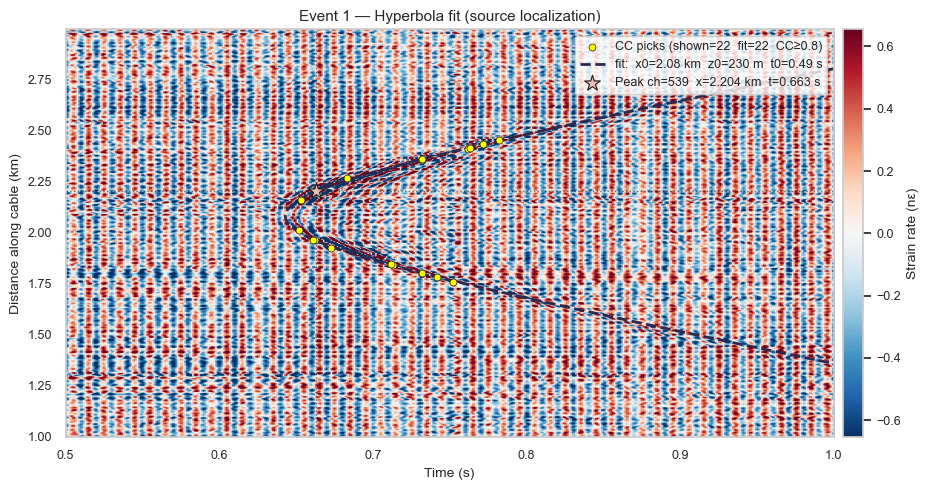

Saved hyperbola fit plot


In [430]:
# =============================================================================
# SOURCE LOCALISATION — HYPERBOLA FIT  (§5)
# Model: t(x) = t0 + sqrt((x-x0)^2 + z0^2) / c_water
# CC picks (quality >= CC_THRESH) provide measured arrival times.
# curve_fit jointly estimates (x0, z0, t0); z0 init from pick geometry.
#
# Gives x0 (continuous, not quantized to channel spacing) and z0
# (source-cable distance, mainly horizontal offset in shallow water).
# Uses relative delays dt(x) = [sqrt((x-x0)^2+z0^2) - z0]/c to
# eliminate t0/z0 correlation. t0 back-calculated as t0 = t_peak - z0/c.
# =============================================================================
from scipy.optimize import curve_fit

# ── Peak channel ──────────────────────────────────────────────────────────
# Use anomaly window from detection cell
mt_pk  = (time_vec >= t_window_anomaly[0]) & (time_vec <= t_window_anomaly[1])
env_peak = np.abs(hilbert(strain_acoustic[mt_pk, :], axis=0))

peak_ch   = ch_local                                               # unified with single-channel analysis
peak_tidx = int(np.where(mt_pk)[0][0]) + int(np.argmax(env_peak[:, peak_ch]))
t_peak    = time_vec[peak_tidx]
x_peak    = distance[peak_ch]
print(f"Peak ch={first_ch+peak_ch}  x={x_peak/1000:.3f} km  t={t_peak:.3f} s")

# ── CC picks ──────────────────────────────────────────────────────────────
half_tmpl = int(0.06 * fs)
CC_THRESH = 0.8
i_s = max(0, peak_tidx - half_tmpl)
i_e = min(n_time, peak_tidx + half_tmpl)
tmpl     = strain_filtered[i_s:i_e, peak_ch].copy()
tmpl_rms = np.sqrt(np.mean(tmpl**2)) + 1e-30

dt_rel  = np.full(n_space, np.nan)
cc_qual = np.zeros(n_space)
for i in range(n_space):
    dx_i   = abs(distance[i] - x_peak)
    margin = 0.10
    i0 = max(0,      peak_tidx - int((dx_i/c_water + margin) * fs))
    i1 = min(n_time, peak_tidx + int((dx_i/c_water + margin) * fs))
    seg = strain_filtered[i0:i1, i]
    if len(seg) < len(tmpl):
        continue
    cc      = correlate(seg, tmpl, mode='valid')
    lag_smp = int(np.argmax(cc))
    seg_win    = seg[lag_smp: lag_smp + len(tmpl)]
    seg_rms    = np.sqrt(np.mean(seg_win**2)) + 1e-30
    cc_qual[i] = cc[lag_smp] / (len(tmpl) * seg_rms * tmpl_rms)
    dt_rel[i]  = time_vec[i0 + lag_smp + half_tmpl] - t_peak

good = ~np.isnan(dt_rel) & (cc_qual >= CC_THRESH)
t_picks_abs = t_peak + dt_rel
good_plot   = good & (t_picks_abs >= t_window_anomaly[0]) & (t_picks_abs <= t_window_anomaly[1])
print(f"Picks for fit: {good.sum()}   shown in plot: {good_plot.sum()}  (CC≥{CC_THRESH})")

# ── Fit ───────────────────────────────────────────────────────────────────
def t_hyperbola(x, x0, z0, t0):
    return t0 + np.sqrt((x - x0)**2 + z0**2) / c_water

# Auto-estimate z0 from pick geometry: z0 ≈ Δx² / (2·c·Δt)
dx_picks = np.abs(distance[good] - x_peak)
dt_picks = t_picks_abs[good] - t_peak          # >= 0 by construction
valid_p  = dt_picks > 0.002                    # exclude near-zero delays
if valid_p.sum() >= 2:
    z0_init = float(np.median(dx_picks[valid_p]**2 /
                              (2 * c_water * dt_picks[valid_p])))
    z0_init = float(np.clip(z0_init, 50.0, 2000.0))
else:
    z0_init = 350.0
print(f"z0 auto-estimate: {z0_init:.0f} m")

popt, pcov = curve_fit(t_hyperbola, distance[good], t_picks_abs[good],
                        p0=[x_peak, z0_init, t_peak - z0_init/c_water],
                        bounds=([distance[0]-2000, 10,  time_vec[0]],
                                [distance[-1]+2000, 5000, t_peak]),
                        maxfev=10000)
x0_fit, z0_fit, t0_fit = popt
perr     = np.sqrt(np.diag(pcov))
# t0_fit from popt
resid_ms = np.std(t_picks_abs[good] - t_hyperbola(distance[good], *popt)) * 1000

print(f"\n── Hyperbola fit ────────────────────────────────────────────────")
print(f"  x0 = {x0_fit/1000:.3f} +/- {perr[0]/1000:.3f} km")
print(f"  z0 = {z0_fit:.0f} +/- {perr[1]:.0f} m")
print(f"  t0 = {t0_fit:.3f} s")
print(f"  RMS residual = {resid_ms:.1f} ms")

# ── Plot ──────────────────────────────────────────────────────────────────
# Centred on anomalous segment with 0.1 s / 0.15 s context on each side
T_PLOT  = (max(time_vec[0],  t_window_anomaly[0] ),
           min(time_vec[-1], t_window_anomaly[1] ))
mt_pl   = (time_vec >= T_PLOT[0]) & (time_vec <= T_PLOT[1])
clim    = np.nanpercentile(np.abs(strain_filtered[mt_pl, :]), 95)
ext     = [T_PLOT[0], T_PLOT[1], distance[0]/1000, distance[-1]/1000]
t_curve_abs = t_hyperbola(distance, x0_fit, z0_fit, t0_fit)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(strain_filtered[mt_pl, :].T, aspect='auto', origin='lower',
               extent=ext, cmap='RdBu_r', vmin=-clim, vmax=clim)
plt.colorbar(im, ax=ax, label='Strain rate (nε)', pad=0.01)
ax.scatter(t_picks_abs[good_plot], distance[good_plot]/1000,
           s=25, c='yellow', edgecolors='k', linewidths=0.5,
           zorder=5, label=f'CC picks (shown={good_plot.sum()}  fit={good.sum()}  CC≥{CC_THRESH})')
ax.plot(t_curve_abs, distance/1000, color=blue3, lw=2.0, ls='--',
        label=f'fit:  x0={x0_fit/1000:.2f} km  z0={z0_fit:.0f} m  t0={t0_fit:.2f} s')
ax.axhline(x_peak/1000, color="k", lw=1.0, ls=":", alpha=0.6)
ax.axvline(t_peak,      color="k", lw=1.0, ls=":", alpha=0.6)
ax.scatter([t_peak], [x_peak/1000], s=140, marker="*",
           c=red1, edgecolors="k", linewidths=0.8, zorder=6,
           label=f"Peak ch={first_ch+peak_ch}  x={x_peak/1000:.3f} km  t={t_peak:.3f} s")
ax.set_xlabel('Time (s)', fontsize=10)
ax.set_ylabel('Distance along cable (km)', fontsize=10)
ax.set_title(f'Event {event_id} — Hyperbola fit (source localization)', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(T_PLOT)
plt.tight_layout()
plt.savefig(f'plots/hyperbola_fit.png', dpi=150)
plt.show()
print('Saved hyperbola fit plot')

Farthest CC pick: ch=430  x=1.759 km  tau_cc=89.0 ms
  Single channel (peak)       : 9.5 dB  gain=+0.0 dB
  Farthest CC ch=430          : 2.5 dB  gain=-7.1 dB
  CC N=22 model               : 8.2 dB  gain=-1.3 dB
  CC N=22 measured            : 7.6 dB  gain=-1.9 dB


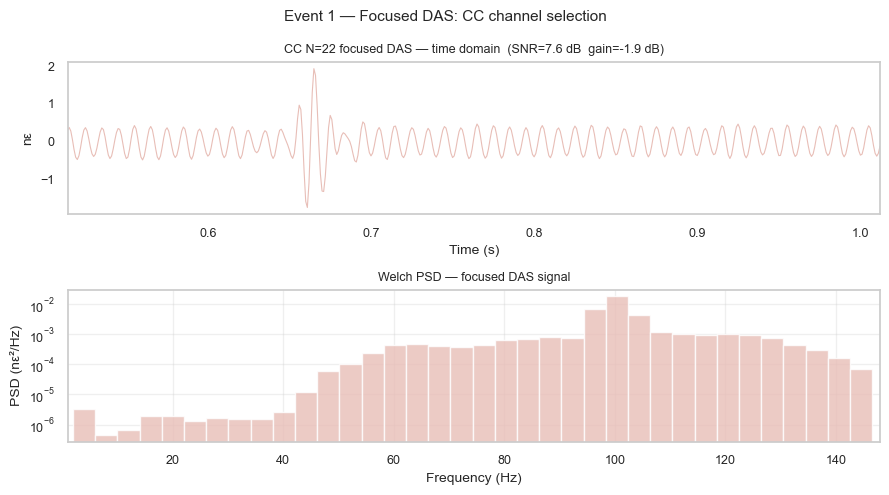

Saved plots/focused_das.png


In [431]:
# FOCUSED DAS + CLASSIFICATION FEATURES  (§6, §7)
# Spherical-wave delays align CC-pick channels for coherent summation.
# Output: beamformed waveform (time) + Welch PSD (frequency).
# Combined feature vector enables event classification (RF, SVM, 1-D CNN).
# =============================================================================
x0_rel      = x0_fit - distance[0]
tau_focused = np.sqrt((x_rel - x0_rel)**2 + z0_fit**2) / c_water
tau_rel     = tau_focused - tau_focused[ch_local]

tau_max     = float(tau_focused.max())
t_foc_start = max(time_vec[0],  t0_fit - 0.05)
t_foc_end   = min(time_vec[-1], t0_fit + tau_max + 0.15)
mt_wide     = (time_vec >= t_foc_start) & (time_vec <= t_foc_end)
n_wide      = int(mt_wide.sum())
t_wide      = time_vec[mt_wide]

# ── CC pick channels ───────────────────────────────────────────────────────
good_idx   = np.where(good)[0]
n_good     = int(good.sum())
tau_cc_rel = t_picks_abs[good] - t_peak
tau_md_rel = tau_rel[good]

# Farthest CC pick channel from peak channel
far_pos    = np.argmax(np.abs(good_idx - ch_local))
far_local  = good_idx[far_pos]
far_dist   = distance[far_local] / 1000
far_ch_idx = first_ch + far_local
far_tau_cc = float(tau_cc_rel[far_pos])   # measured CC delay for this channel
print(f"Farthest CC pick: ch={far_ch_idx}  x={far_dist:.3f} km  tau_cc={far_tau_cc*1000:.1f} ms")

# ── Frequency-domain DAS ───────────────────────────────────────────────────
F_foc  = np.fft.rfft(strain_acoustic[mt_wide, :], axis=0).astype(np.complex64)
f_foc  = np.fft.rfftfreq(n_wide, d=1/fs).astype(np.float32)
F_good = F_foc[:, good_idx]

# Farthest channel: time-shift only (no summation), align to t_peak
steer_far  = np.exp(+1j * 2*np.pi * f_foc * far_tau_cc).astype(np.complex64)
far_aligned = np.fft.irfft(steer_far * F_foc[:, far_local], n=n_wide).astype(np.float32)

# CC channel focused DAS
steer_md = np.exp(+1j * 2*np.pi * np.outer(f_foc, tau_md_rel.astype(np.float32))).astype(np.complex64)
beam_md  = np.fft.irfft((steer_md * F_good).sum(axis=1) / n_good, n=n_wide).astype(np.float32)

steer_cc = np.exp(+1j * 2*np.pi * np.outer(f_foc, tau_cc_rel.astype(np.float32))).astype(np.complex64)
beam_cc  = np.fft.irfft((steer_cc * F_good).sum(axis=1) / n_good, n=n_wide).astype(np.float32)

# ── Display window ─────────────────────────────────────────────────────────
t_show  = (t_peak - 0.15, t_peak + 0.35)
mt_show = (t_wide >= t_show[0]) & (t_wide <= t_show[1])
t_sv    = t_wide[mt_show]
ref_s   = strain_acoustic[mt_wide, :][mt_show, ch_local]
far_s   = far_aligned[mt_show]
md_s    = beam_md[mt_show]
cc_s    = beam_cc[mt_show]

snr_ref = snr_focused_db(ref_s, t_sv, t_peak)
snr_far = snr_focused_db(far_s, t_sv, t_peak)
snr_md  = snr_focused_db(md_s,  t_sv, t_peak)
snr_cc  = snr_focused_db(cc_s,  t_sv, t_peak)
for label, snr in [("Single channel (peak)", snr_ref),
                   (f"Farthest CC ch={far_ch_idx}", snr_far),
                   (f"CC N={n_good} model", snr_md),
                   (f"CC N={n_good} measured", snr_cc)]:
    print(f"  {label:28s}: {snr:.1f} dB  gain={snr-snr_ref:+.1f} dB")

# ── Combined: time-domain (top) + Welch PSD (bottom) ───────────────────────
WIN_PSD = min(256, len(cc_s) // 2)
NOV_PSD = WIN_PSD * 3 // 4
f_w, P_w = welch(cc_s.astype(np.float64), fs=fs,
                 nperseg=WIN_PSD, noverlap=NOV_PSD)
fm  = (f_w >= lowcut) & (f_w <= highcut)
bw  = f_w[1] - f_w[0]

fig, (ax_t, ax_f) = plt.subplots(2, 1, figsize=(9, 5))

# Time-domain: focused DAS signal
ax_t.plot(t_sv, cc_s, color=red1, lw=0.8)
ax_t.set_ylabel("nε", fontsize=10)
ax_t.set_xlabel("Time (s)", fontsize=10)
ax_t.set_title(f"CC N={n_good} focused DAS — time domain  (SNR={snr_cc:.1f} dB  gain={snr_cc-snr_ref:+.1f} dB)", fontsize=9)
ax_t.margins(x=0)

# Frequency-domain: Welch PSD
ax_f.bar(f_w[fm], P_w[fm], width=bw, color=red1, alpha=0.8)
ax_f.set_yscale("log")
ax_f.set_xlabel("Frequency (Hz)", fontsize=10)
ax_f.set_ylabel("PSD (nε²/Hz)", fontsize=10)
ax_f.set_title("Welch PSD — focused DAS signal", fontsize=9)
ax_f.set_xlim(lowcut, highcut)
ax_f.grid(True, alpha=0.3)

plt.suptitle(f"Event {event_id} — Focused DAS: CC channel selection", fontsize=11)
plt.tight_layout()
plt.savefig(f"plots/focused_das.png", dpi=150)
plt.show()
print(f"Saved plots/focused_das.png")